# 20장-2 전이학습, 데이터 증식 - 뇌 사진 예제

https://keras.io/api/applications/

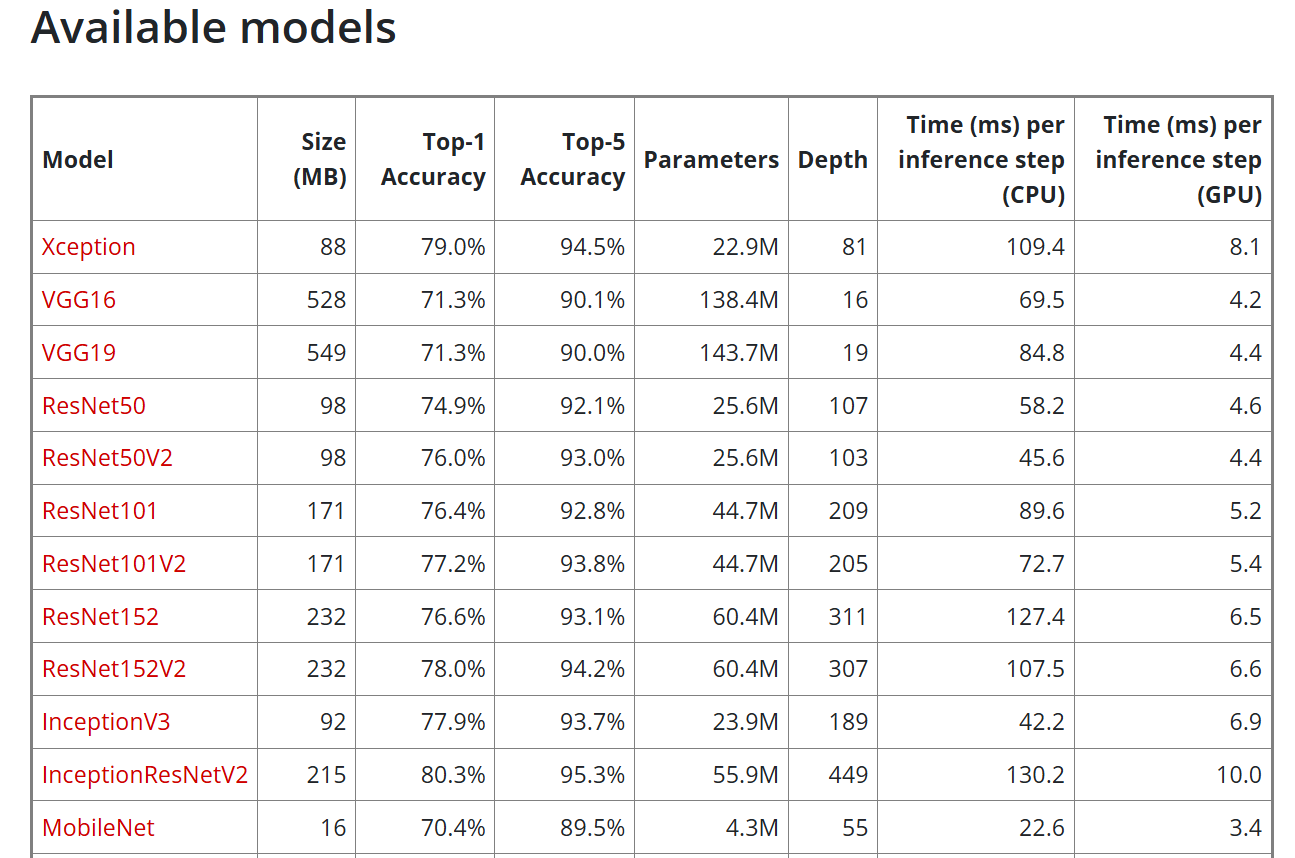

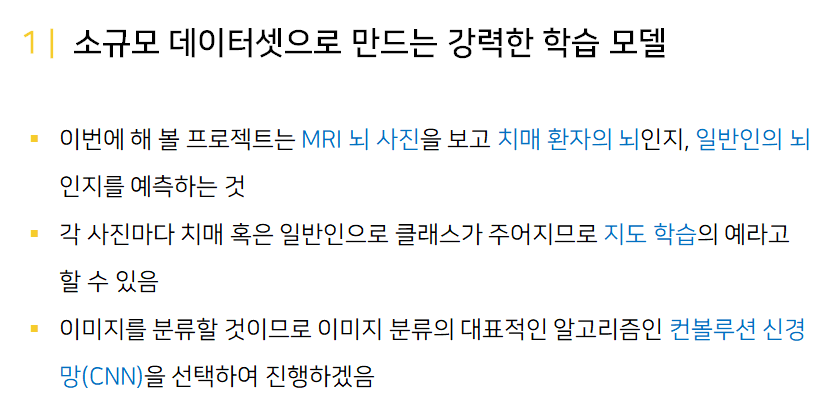

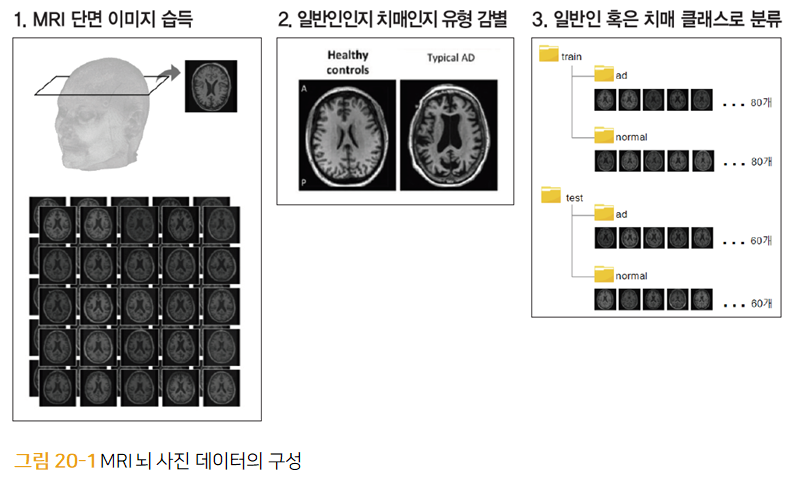

먼저 치매환자의 뇌 MRI를 확인하여 보자.

In [ ]:
import glob
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 15))
img_paths = glob.glob('../cnn_data/brain_MRI_images/test/ad/*.jpg')
len(img_paths)

In [ ]:
plt.figure(figsize=(15, 15))
for i, img_path in enumerate(img_paths):
    if i > 24: 
        break
    img = plt.imread(img_path)
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
plt.show()

이제 일반인의 뇌 MRI를 확인해 보자.

In [ ]:
## glob으로 읽어서 찍어보기 (파일 이름을 모를 때)
import glob
img_path_list = glob.glob('../cnn_data/brain_MRI_images/test/normal/*.*')
## 10개의 ad 이미지를 화면에 표시해보기 (총 80개 데이터)
plt.figure(figsize=(15, 15))
for i, img_path in enumerate(img_path_list):
    img = plt.imread(img_path)
#     img = np.array(PIL.Image.open(img_path))
    plt.subplot(5, 5, i+1)
    plt.imshow(img)
    if i >= 9:
        break
plt.show()

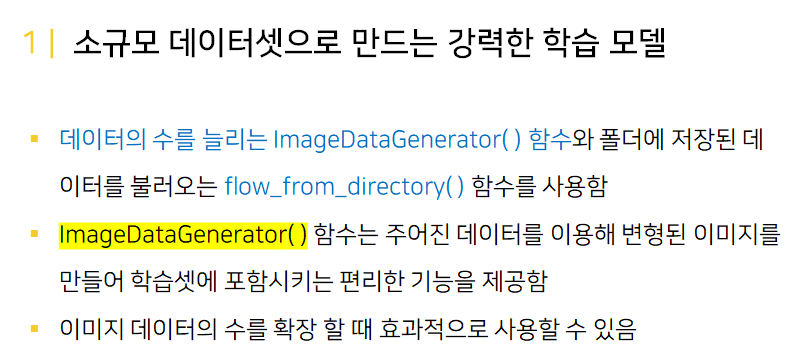

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 학습셋의 변형을 설정하는 부분입니다. 
train_datagen = ImageDataGenerator(rescale=1./255,          # 주어진 이미지의 크기를 설정합니다.
                                  horizontal_flip=True,     # 수평 대칭 이미지를 50% 확률로 만들어 추가합니다.
                                  width_shift_range=0.1,    # 전체 크기의 15% 범위에서 좌우로 이동합니다.
                                  height_shift_range=0.1,   # 마찬가지로 위, 아래로 이동합니다.
                                  #rotation_range=5,        # 정해진 각도만큼 회전시킵니다.
                                  #shear_range=0.7,         # 좌표 하나를 고정시키고 나머지를 이동시킵니다.
                                  #zoom_range=[0.8, 1.2],   # 확대 또는 축소시킵니다.
                                  #vertical_flip=True,      # 수직 대칭 이미지를 만듭니다.
                                  fill_mode='nearest'      # 빈 공간을 채우는 방법입니다. nearest 옵션은 가장 비슷한 색으로 채우게 됩니다.
                                  )      

train_generator = train_datagen.flow_from_directory(
       '../cnn_data/brain_MRI_images/train',   # 학습셋이 있는 폴더의 위치입니다.
       target_size=(150, 150),
       batch_size=5,
       class_mode='binary')

In [ ]:
# 테스트셋은 이미지 부풀리기 과정은 없이, rescale 만 진행
test_datagen = ImageDataGenerator(rescale=1./255)  

test_generator = test_datagen.flow_from_directory(
       '../cnn_data/brain_MRI_images/test',   # 테스트셋이 있는 폴더의 위치입니다.
       target_size=(150, 150),
       batch_size=5,
       class_mode='binary')

In [ ]:
# 앞서 배운 CNN 모델을 만들어 적용해 보겠습니다.
model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=(150,150,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))
model.summary()

In [ ]:
## 모델 컴파일
adam = optimizers.Adam(learning_rate=0.0002)
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

In [ ]:
## 콜백함수 정의
# 학습의 조기 중단을 설정합니다.
checkpoint_callback = ModelCheckpoint('BrainMRI_model.keras', monitor='val_loss', 
                                      save_best_only=True, 
                                      verbose=1)
early_stopping_callback = EarlyStopping(monitor='val_loss', 
                                        patience=5,
                                        restore_best_weights=True)

In [ ]:
#모델을 실행합니다
history = model.fit(
       train_generator, # batch_size=5, 
       steps_per_epoch=32,    # 5 * 32 = 160 data / epoch
       epochs=100,
       validation_data=test_generator,  
       # validation_steps=10,    ## 10 step * 5 data/batch = 50개만 검증에 사용
       validation_steps=24, ## 24 step * 5 data/batch = 120개 전체 데이터 사용 
       # validation_freq=1,
       callbacks=[early_stopping_callback, checkpoint_callback])

In [ ]:
## 학습 과정 시각화
import pandas as pd
import matplotlib.pyplot as plt
df_history = pd.DataFrame(history.history)
df_history[['accuracy', 'val_accuracy']].plot()
plt.grid()
plt.show()

In [ ]:
df_history[['loss', 'val_loss']].plot()
plt.grid()
plt.show()

#### 모델 검증

In [ ]:
## 이미지를 입력하여 예측(검증)
from PIL import Image
base_path = '../cnn_data/brain_MRI_images/'
path = base_path + 'test/normal/normal_test_16.jpg'
test_img = Image.open(path)
test_img

In [ ]:
## 학습 데이터의 shape와 같은지 check!
np.array(test_img).shape

In [ ]:
## 여기서는 (150, 150, 3)으로 모델의 입력 shape와 동일하나... 
## 일반적인 경우 resize를 통해 (150, 150, 3)으로 변환하여 predict 해 주어야 함
test_img_resize = test_img.resize((150, 150))  # PIL image
test_img_resize

In [ ]:
## numpy로 바꾸고... 입력데이터 정규화 
test_img_array = np.array(test_img_resize) / 255.
test_img_array = test_img_array.reshape(-1, 150, 150, 3)
test_img_array.shape

In [ ]:
predicted = model.predict(test_img_array)  ## numpy array...
predicted_idxs = (predicted > 0.5).astype('i')
predicted, predicted_idxs[0, 0]

In [ ]:
## 각 클래스의 이름 확인
train_generator.class_indices

In [ ]:
## key와 value 자리 바꿈
class_name = {v : k for k, v in train_generator.class_indices.items()}
class_name

In [ ]:
class_name[predicted_idxs[0][0]]

In [ ]:
##################################################
#  치매환자의 MRI(0) 검증
##################################################
right_cnt = 0
for i in range(1, 61):
    test_img = Image.open(base_path + f'test/ad/ad_test_{i}.jpg')
    test_img_array = np.array(test_img) / 255.
    predicted = model.predict(test_img_array[np.newaxis,:, :, :], verbose=0).round()[0, 0]
    print(f"({i}) {predicted}", end='  ')
    if predicted == 0:  # 치매환자의 뇌
        right_cnt += 1
print(f"\n정답 수: {right_cnt}/{i},  Accuracy: {right_cnt / i}, Total sample: {i}")

In [ ]:
##################################################
#  정상환자의 MRI(1) 검증
##################################################
right_cnt = 0
wrong_idx = [] 
for i in range(1, 61):
    test_img = Image.open(base_path + f'test/normal/normal_test_{i}.jpg')
    test_img_array = np.array(test_img) / 255.
    predicted = model.predict(test_img_array[np.newaxis,:, :, :], verbose=0).round()[0, 0]
    print(f"({i}) {predicted}", end='  ')
    if predicted == 1:  # 치매환자의 뇌
        right_cnt += 1
    else: 
        wrong_idx.append(i)
print(f"\n정답 수: {right_cnt}/{i},  Accuracy: {right_cnt / i}, Total sample: {i}")

In [ ]:
wrong_idx

## 전이학습

* **vgg16 모델의 구조**

In [ ]:
from tensorflow.keras.applications import VGG16, MobileNetV2

model_vgg16 = VGG16(weights='imagenet')
# model_vgg16.summary()

In [ ]:
model_MobileNetV2 = MobileNetV2(weights='imagenet')
model_MobileNetV2.summary()

* include_top=False, input_shape=(150, 150, 3)

In [ ]:
from tensorflow.keras.applications import VGG16

model_vgg16 = VGG16(weights='imagenet', 
                    include_top=False, 
                    input_shape=(150, 150, 3))
model_vgg16.summary()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Input, models, layers, optimizers, metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Activation, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3, MobileNetV2  # 모델 불러오기!!!
import numpy as np
import matplotlib.pyplot as plt

# 학습셋의 변형을 설정하는 부분입니다. 
train_datagen = ImageDataGenerator(rescale=1./255,          # 주어진 이미지의 크기를 설정합니다.
                                  horizontal_flip=True,     # 수평 대칭 이미지를 50% 확률로 만들어 추가합니다.
                                  width_shift_range=0.2,    # 전체 크기의 15% 범위에서 좌우로 이동합니다.
                                  height_shift_range=0.2,   # 마찬가지로 위, 아래로 이동합니다.
                                  rotation_range=5,        # 정해진 각도만큼 회전시킵니다.
                                  #shear_range=0.7,         # 좌표 하나를 고정시키고 나머지를 이동시킵니다.
                                  zoom_range=[0.8, 1.2],   # 확대 또는 축소시킵니다.
                                  #vertical_flip=True,      # 수직 대칭 이미지를 만듭니다.
                                  fill_mode='nearest'      # 빈 공간을 채우는 방법입니다. nearest 옵션은 가장 비슷한 색으로 채우게 됩니다.
                                  )      

train_generator = train_datagen.flow_from_directory(
       '../cnn_data/brain_MRI_images/train',   # 학습셋이 있는 폴더의 위치입니다.
       target_size=(150, 150),
       batch_size=5,
       class_mode='binary')

In [ ]:
# 테스트셋의 정규화를 설정합니다.
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
       '../cnn_data/brain_MRI_images/test',
       target_size=(150, 150),
       batch_size=5,
       class_mode='binary')

In [ ]:
## VGG모델 불러오기 
# transfer_model = VGG16(weights='imagenet', 
transfer_model = MobileNetV2(weights='imagenet', 
                       include_top=False,         # Flatten 이후는 포함하지 않고 가져옴옴
                       input_shape=(150, 150, 3)) # 기본 (224, 224, 3)을 변경
transfer_model.trainable = False    # Pretrained Model의 파라미터는 학습하지 않음!!!
# transfer_model.summary()

In [ ]:
## Model Finetunning 미세조정
finetune_model = Sequential()
finetune_model.add(transfer_model)   # Pretrained 모듈을 첫번째 입력으로 받음 !!!
finetune_model.add(Flatten())
finetune_model.add(Dense(64))
finetune_model.add(Activation('relu'))
finetune_model.add(Dropout(0.5))
finetune_model.add(Dense(1, activation='sigmoid'))
finetune_model.summary()

In [ ]:
%%time
# 모델의 실행 옵션을 설정합니다. 
finetune_model.compile(loss='binary_crossentropy',
                       optimizer=optimizers.Adam(learning_rate=0.0002), 
                       metrics=['accuracy'])

# 학습의 조기 중단을 설정합니다.
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5)
# checkpoint_callback = ModelCheckpoint()

# 모델을 실행합니다.
history = finetune_model.fit(
       train_generator,
       # steps_per_epoch=20,
       epochs=20,
       validation_data=test_generator,
       validation_steps=10, 
       callbacks=[early_stopping_callback])

In [ ]:
import pandas as pd
df_history = pd.DataFrame(history.history)
df_history[['loss', 'val_loss']].plot()
plt.show()

In [ ]:
df_history[['accuracy', 'val_accuracy']].plot()
plt.show()

In [ ]:
# 테스트 셋 : rescale 만 진행
test_datagen = ImageDataGenerator(rescale=1./255)  

test_generator = test_datagen.flow_from_directory(
       '../cnn_data/brain_MRI_images/test',   # 테스트셋이 있는 폴더의 위치입니다.
       target_size=(150, 150),  # resize
       # batch_size=10,  # batch_size는 결과에는 영향이 없으나, 메모리 사용이 달라짐
       class_mode='binary')

predict = finetune_model.predict(test_generator)

In [ ]:
predict.shape

In [ ]:
# predict  # sigmoid값값

In [ ]:
predict.round().astype(int)